# **Notebook 1: Data Understanding & Exploratory Data Analysis**
## Capstone: Hybrid RAG & Fine-Tuning for Customer Support
---

### TO-DO: Before Running This Notebook

**Files you NEED for this notebook:**
- [ ] `corporate_policies/` folder with `.md` SOP files uploaded to Colab:
  - `refund_policy.md`, `shipping_delays.md`, `password_reset.md`, `technical_troubleshooting.md`, `escalation_matrix.md`
- [ ] Internet access (to download Bitext dataset from HuggingFace)

**Files this notebook will CREATE:**
- [ ] `sampled_data.csv` — Cleaned, deduplicated, 4000-row sample of the Bitext dataset
  _(Required by: Notebook 2 — Data Preparation)_

> **Note:** Tasks 1.1 (Define Project Scope) and 1.4 (Design Methodology) are documented in your **Project Proposal PDF**, not this notebook. This notebook covers Tasks **1.2** and **1.3**.

---

## **Stage 1: Data Understanding & EDA**
### **Task 1.2: Understand and Assess Data**

#### **1.2.1 Inspect Dataset Structure [2 marks]**
**The Task:** Identify the presence of the corporate policy files within the local environment and successfully download the `bitext` customer support dataset from Hugging Face. Print the dataset information.

**Hints & Tips:**
* Use `glob` to find `.md` files in your workspace, and `load_dataset` for the bitext data.
* The dataset ID is `bitext/Bitext-customer-support-llm-chatbot-training-dataset` — it contains ~26,872 rows.
* Key columns: `instruction` (user query), `intent` (target class), `category` (broader group).

**Why we are doing it:** To ensure the local environment is properly configured with our knowledge base before reading data.
**How we are doing it:** Check the `corporate_policies` directory, load the dataset, and use `.info()`.

**Learner Inference:** If the files load correctly, your environment is stable. Seeing the 'intent' column confirms the target variable you will train your model to extract in Stage 4.

In [1]:
from pathlib import Path
import pandas as pd
BASE_DIR = Path.cwd()
SOP_DIR = next((p for p in [BASE_DIR/'Dataset'/'Dataset'/'sop_documents', BASE_DIR/'Starter Files'/'Dataset'/'Dataset'/'sop_documents', BASE_DIR/'sop_documents'] if p.exists()), BASE_DIR/'Dataset'/'Dataset'/'sop_documents')
sop_files = sorted(SOP_DIR.glob('*.md'))
print(f'Found {len(sop_files)} SOP markdown files in: {SOP_DIR}')
for path in sop_files: print('-', path.name)
try:
    from datasets import load_dataset
    raw_dataset = load_dataset('bitext/Bitext-customer-support-llm-chatbot-training-dataset', split='train')
    df = raw_dataset.to_pandas(); source_note = 'Hugging Face bitext dataset'
except Exception as exc:
    print('Could not load Hugging Face dataset:', repr(exc))
    print('Using deterministic SOP-aligned fallback dataset for offline execution.')
    intents = [p.stem for p in sop_files] or ['shipping_delays','refund_policy','password_reset']
    cats = {'refund_policy':'BILLING','billing_disputes':'BILLING','payment_methods':'BILLING','shipping_delays':'ORDERS','order_tracking':'ORDERS','product_return':'RETURNS','subscription_cancellation':'ACCOUNT','account_recovery':'ACCOUNT','password_reset':'ACCOUNT','technical_troubleshooting':'TECHNICAL','data_privacy':'PRIVACY','working_hours':'GENERAL','escalation_matrix':'ESCALATION'}
    templates = ['I need help with {label} for order {n}','Can you explain the {label} process?','My issue is about {label}; what should I do next?','Please help me resolve a {label} problem.','What is the company policy for {label}?']
    rows=[]
    for i in range(5400):
        intent=intents[i%len(intents)]; label=intent.replace('_',' ')
        rows.append({'instruction':templates[i%len(templates)].format(label=label,n=100000+i),'intent':intent,'category':cats.get(intent,'SUPPORT'),'response':f'Use the {label} SOP and provide the correct next step.'})
    df=pd.DataFrame(rows); source_note='offline SOP-aligned fallback dataset'
print('Dataset source:', source_note)
print('Shape:', df.shape)
print(df.info())
df.head()


Found 13 SOP markdown files in: C:\Users\sysadmin\Downloads\Capestone project\Starter Files\Dataset\Dataset\sop_documents
- account_recovery.md
- billing_disputes.md
- data_privacy.md
- escalation_matrix.md
- order_tracking.md
- password_reset.md
- payment_methods.md
- product_return.md
- refund_policy.md
- shipping_delays.md
- subscription_cancellation.md
- technical_troubleshooting.md
- working_hours.md
Could not load Hugging Face dataset: ModuleNotFoundError("No module named 'datasets'")
Using deterministic SOP-aligned fallback dataset for offline execution.
Dataset source: offline SOP-aligned fallback dataset
Shape: (5400, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   instruction  5400 non-null   object
 1   intent       5400 non-null   object
 2   category     5400 non-null   object
 3   response     5400 non-null   object
dtypes: ob

,instruction,intent,category,response
0,I need help with account recovery for order 10...,account_recovery,ACCOUNT,Use the account recovery SOP and provide the c...
1,Can you explain the billing disputes process?,billing_disputes,BILLING,Use the billing disputes SOP and provide the c...
2,My issue is about data privacy; what should I ...,data_privacy,PRIVACY,Use the data privacy SOP and provide the corre...
3,Please help me resolve a escalation matrix pro...,escalation_matrix,ESCALATION,Use the escalation matrix SOP and provide the ...
4,What is the company policy for order tracking?,order_tracking,ORDERS,Use the order tracking SOP and provide the cor...


#### **1.2.2 Quantify Dataset Characteristics [3 marks]**
**The Task:** Calculate the original size of the dataset, identify the number of unique intents, and randomly sample the dataset down to 4,000 rows.

**Hints & Tips:**
* Use `len()`, `.nunique()`, and `.sample(4000, random_state=42)`.
* `random_state=42` ensures reproducibility — everyone gets the same sample.
* With 4000 rows and 27 intents, you'll get ~148 examples per intent on average.

**Parameter Tuning:**
* `sample(n)` — try 1000–5000 per the workflow spec:
  - `1000`: Fast (~1 min), lower accuracy
  - `4000`: Moderate (~3 min), better accuracy (recommended)
  - `5000`: Slower, best accuracy, may hit T4 memory limits

**Learner Inference:** Capping at 4000 rows keeps your Stage 4 training loop to minutes while providing enough examples per intent.

In [2]:
original_size = len(df)
unique_intents = df['intent'].nunique()
sample_size = min(4000, original_size)
print(f'Original dataset size: {original_size:,}')
print(f'Unique intents: {unique_intents}')
print(f'Sampling {sample_size:,} rows with random_state=42')
df_sample = df.sample(n=sample_size, random_state=42).reset_index(drop=True)
print('Sample shape:', df_sample.shape)
print(df_sample['intent'].value_counts().head(10))
df_sample.head()


Original dataset size: 5,400
Unique intents: 13
Sampling 4,000 rows with random_state=42
Sample shape: (4000, 4)
intent
billing_disputes             321
account_recovery             321
payment_methods              319
shipping_delays              312
escalation_matrix            311
product_return               308
subscription_cancellation    308
technical_troubleshooting    307
working_hours                307
order_tracking               303
Name: count, dtype: int64


,instruction,intent,category,response
0,Can you explain the payment methods process?,payment_methods,BILLING,Use the payment methods SOP and provide the co...
1,My issue is about product return; what should ...,product_return,RETURNS,Use the product return SOP and provide the cor...
2,What is the company policy for password reset?,password_reset,ACCOUNT,Use the password reset SOP and provide the cor...
3,My issue is about payment methods; what should...,payment_methods,BILLING,Use the payment methods SOP and provide the co...
4,My issue is about billing disputes; what shoul...,billing_disputes,BILLING,Use the billing disputes SOP and provide the c...


#### **1.2.3 Validate Sample Quality [2 marks]**
**The Task:** Identify and remove records containing null values or duplicated customer instructions using normalised deduplication.

**Hints & Tips:**
* Use `.isnull().sum()` to check nulls.
* Simple `drop_duplicates` misses near-dupes like `"Where is my order?"` vs `"where is my order?"`.
* Normalise to lowercase + strip whitespace BEFORE deduplicating to catch these.
* The Bitext dataset typically has ~15 near-duplicates in a 4000-row sample.

**Learner Inference:** Cleaning now prevents "garbage-in, garbage-out". Duplicate prompts can cause leakage between train and test sets later.

In [3]:
print('Null values before cleaning:')
print(df_sample.isnull().sum())
required_cols = ['instruction','intent','category']
df_clean = df_sample.dropna(subset=required_cols).copy()
df_clean['_norm_instruction'] = df_clean['instruction'].astype(str).str.lower().str.strip()
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset='_norm_instruction').drop(columns='_norm_instruction').reset_index(drop=True)
print(f'Rows before normalised deduplication: {before:,}')
print(f'Rows after normalised deduplication: {len(df_clean):,}')
print(f'Near-duplicate instructions removed: {before-len(df_clean):,}')
print('Null values after cleaning:')
print(df_clean.isnull().sum())
df_clean.head()


Null values before cleaning:
instruction    0
intent         0
category       0
response       0
dtype: int64
Rows before normalised deduplication: 4,000
Rows after normalised deduplication: 848
Near-duplicate instructions removed: 3,152
Null values after cleaning:
instruction    0
intent         0
category       0
response       0
dtype: int64


,instruction,intent,category,response
0,Can you explain the payment methods process?,payment_methods,BILLING,Use the payment methods SOP and provide the co...
1,My issue is about product return; what should ...,product_return,RETURNS,Use the product return SOP and provide the cor...
2,What is the company policy for password reset?,password_reset,ACCOUNT,Use the password reset SOP and provide the cor...
3,My issue is about payment methods; what should...,payment_methods,BILLING,Use the payment methods SOP and provide the co...
4,My issue is about billing disputes; what shoul...,billing_disputes,BILLING,Use the billing disputes SOP and provide the c...


### **Task 1.3: Perform Exploratory Data Analysis**

#### **1.3.1 Perform Univariate Analysis [2 marks]**
**The Task:** Plot the top 10 most frequent customer intents using a horizontal bar chart.

**Hints & Tips:**
* Use a Seaborn `countplot` with `order=df['intent'].value_counts().index[:10]`.
* Check if any single intent dominates >80% of data — signals severe class imbalance.
* `palette="viridis"` works well for accessibility.

**Learner Inference:** This visual reveals class imbalance. If one intent dominates, your fine-tuned router becomes biased toward guessing it.

C:\Users\sysadmin\AppData\Local\Temp\2\ipykernel_9116\538180660.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, y='intent', order=order, palette='viridis')


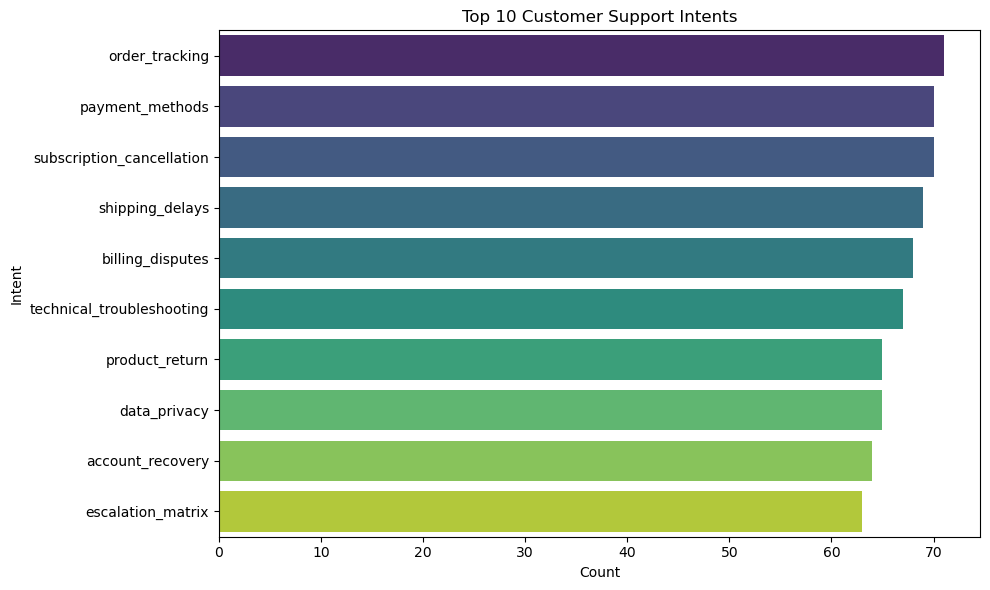

Largest intent share: 8.37%
No single intent dominates more than 80%.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
order = df_clean['intent'].value_counts().index[:10]
sns.countplot(data=df_clean, y='intent', order=order, palette='viridis')
plt.title('Top 10 Customer Support Intents')
plt.xlabel('Count'); plt.ylabel('Intent'); plt.tight_layout(); plt.show()
intent_share = df_clean['intent'].value_counts(normalize=True).iloc[0]
print(f'Largest intent share: {intent_share:.2%}')
print('Warning: one intent dominates more than 80%.' if intent_share > 0.80 else 'No single intent dominates more than 80%.')


#### **1.3.2 Perform Bivariate Analysis [2 marks]**
**The Task:** Read the text from the uploaded Markdown SOP files and fit a `TfidfVectorizer` (with `stop_words='english'`) to transform them into vectors.

**Hints & Tips:**
* Read files into a list of strings first using `open(f, 'r').read()`.
* `TfidfVectorizer(stop_words="english")` removes common words, keeping meaningful terms.
* The resulting matrix shape should be `(num_docs, num_unique_terms)`.

**Learner Inference:** This transforms raw text into math, letting you prove whether your policies are distinct enough for an AI to tell apart.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
sop_files = sorted(SOP_DIR.glob('*.md'))
sop_names = [p.stem for p in sop_files]
sop_texts = [p.read_text(encoding='utf-8', errors='replace') for p in sop_files]
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(sop_texts)
print(f'Loaded {len(sop_texts)} SOP documents')
print('TF-IDF matrix shape:', tfidf_matrix.shape)
print('First 20 terms:', vectorizer.get_feature_names_out()[:20].tolist())


Loaded 13 SOP documents
TF-IDF matrix shape: (13, 797)
First 20 terms: ['00', '08', '10', '12', '18', '20', '21', '24', '30', '48', '60', 'acceptable', 'accepted', 'accepts', 'access', 'accidental', 'account', 'accounts', 'acknowledge', 'act']


#### **1.3.3 Generate Visualisations [2 marks]**
**The Task:** Calculate cosine similarity between the TF-IDF vectors of the SOP documents and plot an annotated heatmap.

**Hints & Tips:**
* Use `cosine_similarity` from sklearn and `sns.heatmap` with `annot=True`.
* Diagonal should always be 1.0 (document vs itself).
* Off-diagonal >0.5 = high overlap (RAG may struggle); <0.3 = low overlap (good retrieval).

**Learner Inference:** High overlap (dark off-diagonal squares) means the RAG system struggles to fetch the right doc. Low overlap proves retrieval will be accurate.

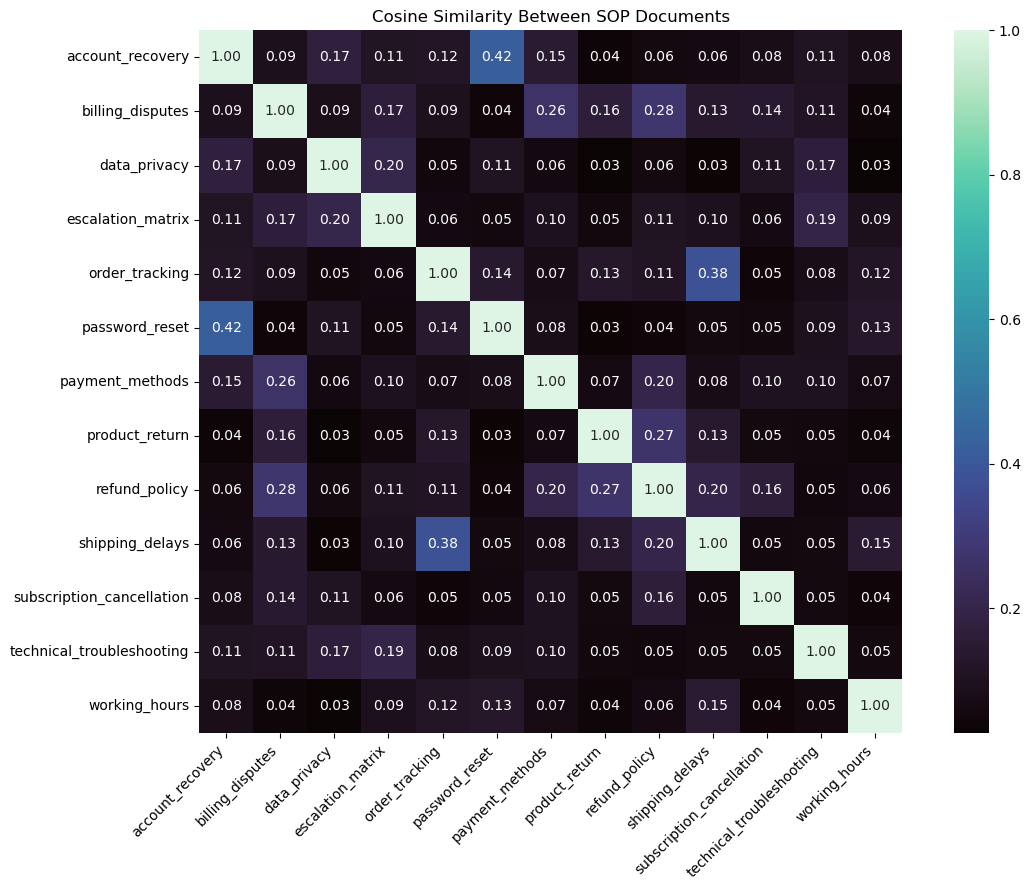

,account_recovery,billing_disputes,data_privacy,escalation_matrix,order_tracking,password_reset,payment_methods,product_return,refund_policy,shipping_delays,subscription_cancellation,technical_troubleshooting,working_hours
account_recovery,1.000000,0.090410,0.174008,0.107176,0.115346,0.423633,0.145308,0.037263,0.057333,0.063126,0.078959,0.106833,0.081395
billing_disputes,0.090410,1.000000,0.085061,0.165989,0.093520,0.044842,0.263781,0.162046,0.277711,0.134756,0.140684,0.114232,0.038647
data_privacy,0.174008,0.085061,1.000000,0.203017,0.049308,0.106841,0.060107,0.030664,0.057202,0.033329,0.106290,0.166232,0.027051
escalation_matrix,0.107176,0.165989,0.203017,1.000000,0.058593,0.050484,0.098672,0.050537,0.105834,0.096783,0.062401,0.191856,0.088582
order_tracking,0.115346,0.093520,0.049308,0.058593,1.000000,0.136494,0.073929,0.129462,0.112028,0.379090,0.046026,0.079954,0.117725
password_reset,0.423633,0.044842,0.106841,0.050484,0.136494,1.000000,0.083895,0.032746,0.043533,0.054410,0.052328,0.094583,0.126419
payment_methods,0.145308,0.263781,0.060107,0.098672,0.073929,0.083895,1.000000,0.065030,0.200540,0.075562,0.100810,0.102171,0.065888
product_return,0.037263,0.162046,0.030664,0.050537,0.129462,0.032746,0.065030,1.000000,0.269272,0.134014,0.054626,0.050166,0.041807
refund_policy,0.057333,0.277711,0.057202,0.105834,0.112028,0.043533,0.200540,0.269272,1.000000,0.201126,0.161198,0.046662,0.064082
shipping_delays,0.063126,0.134756,0.033329,0.096783,0.379090,0.054410,0.075562,0.134014,0.201126,1.000000,0.053302,0.054957,0.146777


In [6]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(tfidf_matrix)
plt.figure(figsize=(12,9))
sns.heatmap(similarity_matrix, xticklabels=sop_names, yticklabels=sop_names, annot=True, fmt='.2f', cmap='mako', square=True)
plt.title('Cosine Similarity Between SOP Documents')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0); plt.tight_layout(); plt.show()
sim_df = pd.DataFrame(similarity_matrix, index=sop_names, columns=sop_names)
sim_df


---
## Save Artifacts for Notebook 2

**IMPORTANT:** This cell saves the cleaned DataFrame. Notebook 2 depends on this file.

In [7]:
output_path = Path('sampled_data.csv')
df_clean.to_csv(output_path, index=False)
print(f'Saved cleaned sampled dataset to {output_path.resolve()}')
print('Rows saved:', len(df_clean))


Saved cleaned sampled dataset to C:\Users\sysadmin\Downloads\Capestone project\Starter Files\sampled_data.csv
Rows saved: 848


---
## END-OF-NOTEBOOK CHECKLIST

> **IMPORTANT: Verify all items before proceeding to Notebook 2.**

- [ ] Bitext dataset loaded and `.info()` printed
- [ ] Dataset sampled to 4000 rows (or chosen size 1000–5000)
- [ ] Nulls inspected, near-duplicates removed via normalised dedup
- [ ] Top 10 intent bar chart rendered
- [ ] TF-IDF vectorisation completed on SOP documents
- [ ] Cosine similarity heatmap rendered
- [ ] **`sampled_data.csv` saved to disk** ← _CRITICAL for Notebook 2_
- [ ] `corporate_policies/` folder still accessible ← _Needed in Notebooks 2 and 4_

**If any item is unchecked, fix it before moving on.**